<a href="https://colab.research.google.com/github/ArthJain123/Customer-Churn-Prediction-ML/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Analysis

In [2]:
data = pd.read_csv("/content/Customer_Churn_Prediction.csv")

# =========================================== Data Analysis ========================================================

print("Top 10 Customers Data: \n",data.head(10))
# print("10 Sample Customers Data: \n",data.sample(10))

print("\n\nTotal Number of Customers: \n",data.shape[0])
print("\nTotal Number of Features/Customer Factors: \n",data.shape[1])

print("\nChecking for Data Type Stored in Each Feature: ")
print(data.info())


obj_dtype = np.array(data.select_dtypes(include = "object").columns)
num_dtype = np.array(data.select_dtypes(include = ["int","float"]).columns)

print("\nFeatures with 'Object' data type: \n",obj_dtype)
print("\nFeatures with 'Numerical' data type: \n",num_dtype)


Top 10 Customers Data: 
    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone servic

## Data Cleaning

In [3]:
# =========================================== Data Cleaning ========================================================

# In dataset ,
# "TotalCharges" feature is 'object' datatype but it should be 'float'
# coverting to float datatype

data["TotalCharges"] = pd.to_numeric(data["TotalCharges"],errors = 'coerce')
print("Verifying, \nThe 'TotalCharges' DataType were converted into 'float': \n",data["TotalCharges"].dtype)

print("\nChecking for Nan/Null in dataset: \n",data.isnull().sum())
# There was 11 null/nan value in TotalCharges Feature.


# I am not removing the Nan/Null but I am replacing it into 0
# Due to ,The Null value customers has tensure 0
# So it is resonable for having TotalCharges = 0

data["TotalCharges"] = data["TotalCharges"].replace(np.nan,0)
print("\nVerifying, \nThat the Nan/Null values were geted replaced with 0: \n",data["TotalCharges"].isnull().sum())

print("\nVerifying ,\nThat there is no single Null/Nan Value in whole dataset: \n",data.isnull().sum())

print("\nChecking for duplicate value in whole Dataset: \n",data.duplicated().sum())
# There is not a single duplicate value in whole dataset


Verifying, 
The 'TotalCharges' DataType were converted into 'float': 
 float64

Checking for Nan/Null in dataset: 
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Verifying, 
That the Nan/Null values were geted replaced with 0: 
 0

Verifying ,
That there is no single Null/Nan Value in whole dataset: 
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
Devi

## EDA on Churn Feature

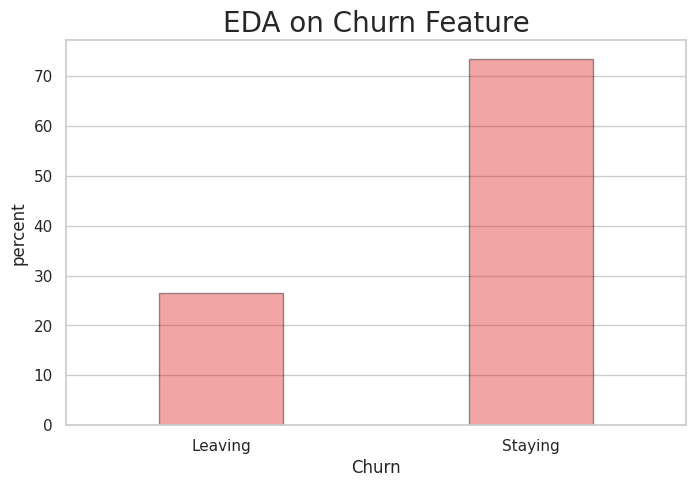


Number of Customers who are Staying: 
 1869

Number of Customers who are Leaving: 
 5174


In [5]:
# ================================== EDA(Exloratory Data Analysis) on Churn Feature ==============================

sns.set(style = "whitegrid")

plt.figure(figsize = (8,5))

plt.title("EDA on Churn Feature",fontsize = 20)

sns.countplot(x = "Churn",data = data,color = "red",width = 0.4,edgecolor = "black",alpha = 0.4,stat = "percent",order = ["Yes","No"])

plt.xticks(["Yes","No"],["Leaving","Staying"])
plt.show()


print("\nNumber of Customers who are Staying: \n",data["Churn"].value_counts().iloc[1])
print("\nNumber of Customers who are Leaving: \n",data["Churn"].value_counts().iloc[0])


# I hypothesis that "Churn" Feature is getting affected by -> TotalCharges,tenure,Contract,Dependents,
                                                            # TechSupport,OnlineSecurity

